In [4]:
import pandas as pd

# 1. Data Loading And Inspection
# Load Dataset
df= pd.read_csv("data/q1_heart_disease.csv")

# Shape, data types, missing values
print("Shape: " , df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing Values:\n ", df.isnull().sum())

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape:  (800, 12)

Data types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
  age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


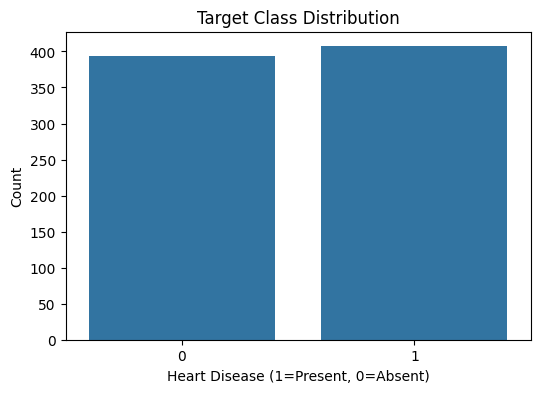

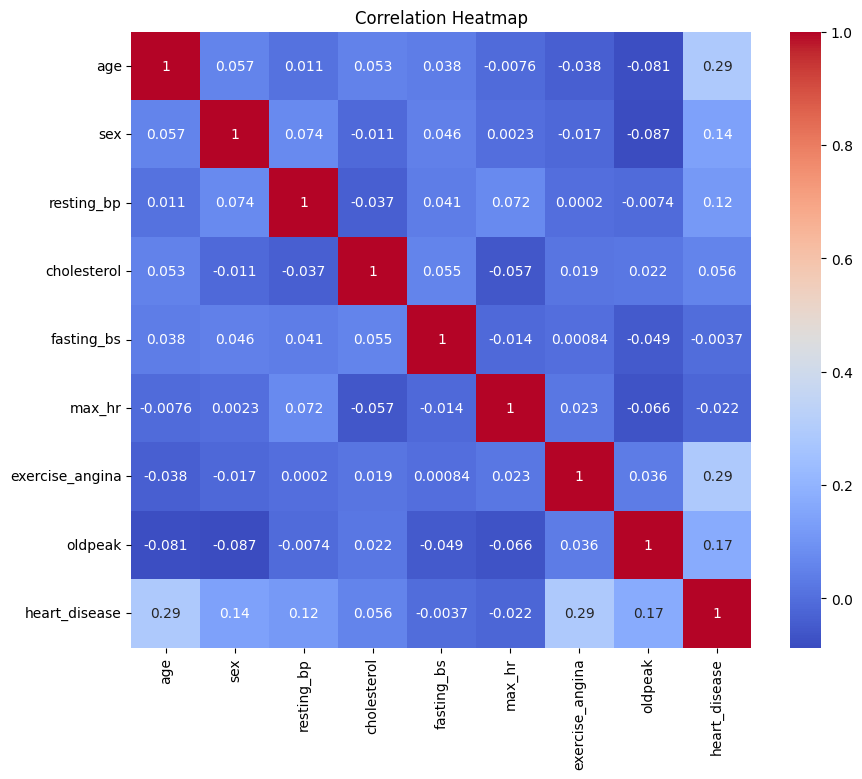

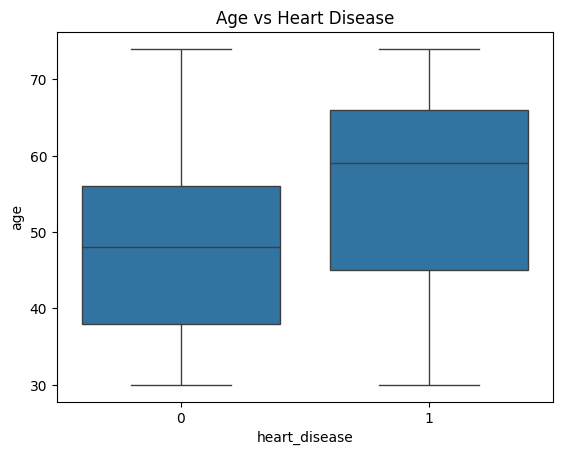

In [5]:
# 2. Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns


# Visualization 1- Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", data=df)  # use color instead of palette
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease (1=Present, 0=Absent)")
plt.ylabel("Count")
plt.show()

# Visualization 2 - Corelation Heatmap 
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Visualization 3 - Age Doistribution By Target
sns.boxplot(x="heart_disease",y="age",data=df)
plt.title("Age vs Heart Disease")
plt.show()







### Interpretation for each plot

Visualization 1- Target distribution
. The dataset shows balanced distribution between patients with and without heart disease. 
. This balamnce is important for training classification models without bias towards one class.

Visualization 2 - Correlation Heatmap 
. Features like oldpeak, resting_bp, cholesterol shpow moderate correlation with the target.
. Age exhibit relation with heart disease, suggesting they might be strong predators. 

Visualization 3 - Age Distribution By Target
. Older people tend to have higher risk of heart disease
. younger patients show lower risk but there are still instances indicating age is influential but not sole factor.


In [7]:
# 3. Data Preprocessing 

# Handle Missing Values
df = df.fillna(df.median(numeric_only=True))

# One hot encoding
df = pd.get_dummies(df, drop_first=True)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

x = df.drop('heart_disease' , axis=1)
y = df['heart_disease']

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

# Train-Test_Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train , y_test = train_test_split(
    x_scaled, y , test_size=0.2 , stratify=y , random_state=42
)

# Model Training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

gb = GradientBoostingClassifier(random_state=42)

dt.fit(x_train, y_train)
rf.fit(x_train, y_train)
gb.fit(x_train, y_train)

# 5. Model Evaluation

from sklearn.metrics import(
    confusion_matrix,
    classification_report
)

# Decision Tree

y_pred_dt = dt.predict(x_test)

print("Decision Tree")

print(confusion_matrix(y_test , y_pred_dt))

print(classification_report(y_test , y_pred_dt))

# Random Forest

y_pred_rf = rf.predict(x_test)

print("Random Forest")

print(confusion_matrix(y_test , y_pred_rf))

print(classification_report(y_test , y_pred_rf))

# Gradient Boosting

y_pred_gb = gb.predict(x_test)

print("Gradient Boosting")

print(confusion_matrix(y_test , y_pred_gb))

print(classification_report(y_test , y_pred_gb))

Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160

Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77  

### Interpretation

- **Decision Tree** : Decent performance but slightly lower precision/recall balance.
- **Random Forest** : Best overall - higher precision, recall, F1 score. Strong generalization due to ensemble averaging.
- **Gradient Boosting**: Solid performance, but slightly below Random Forest in this dataset. 

- **Conclusion:**
The  **Random Forest Classifier**  is the best performing model here with highest F1-score and balanced precision/recall. F1-score is important because it balances precision and recall making it reliable performance metric for classification problems.


In [ ]:
# 6. Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42) 
# Define paramter grid

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5, 10],
    
    'max_features': ['sqrt', 'log2']
}
# Run Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(x_train, y_train)

# Best Parameters
print("Best Parameters:")
print(grid.best_params_)

# Evaluate Tuned Model
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(x_test)

print("\nTuned Model Performance\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report")
print(classification_report(y_test, y_pred_tuned))



Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Performance

Confusion Matrix:

[[59 20]
 [17 64]]

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



**Final Conclusion**
. Tuned model has:
  - More errors (higher FP & FN)
  - Slightly worse balance between classes

*** Baseline Random Forest is better. ***

*** Conclusion ***

. The tuned model underperforms compared to the baseline Random Forest, achieving lower accuracy and F1-score. This indicates that hyperparameter tuning did not improve the model and may have led to suboptimal parameter selection.
. Tuning reduced performance from 79% to 77%, showing that the baseline model is more effective.

